# Plots, widgets and progress bars

Whybook shows what these libraries draw as the notebook does, and the code is the code their documentation shows. The data is synthetic: 200 patients in two arms, seen every week for 12 weeks.

After Run all, try these:

- Watch the bootstrap run: tqdm draws its own bar, and the card and the status bar follow it.
- Drag a box over some points of the Plotly chart, on the bench at Full, in the Code view or in Cell details: the view starts the chart in Box Select, and asks about the rows in the box.
- Move the slider of the ipywidgets cell: the counts under it change.
- Zoom into the ipympl figure with the tools beside it.

The kernel's environment needs numpy and pandas, and `pip install -e ".[plots]" matplotlib ipympl plotnine ninejs` from the repository root.

In [1]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(7)
patients = pd.DataFrame(
    {
        "patient_id": [f"P{i:03d}" for i in range(200)],
        "arm": rng.choice(["A", "B"], size=200),
        "site": rng.choice(["north", "south", "west"], size=200),
        "age": rng.integers(18, 70, size=200),
    }
)
visits = patients.loc[patients.index.repeat(12)].reset_index(drop=True)
visits["week"] = np.tile(np.arange(1, 13), 200)
slope = np.where(visits.arm == "B", -0.12, -0.05)
visits["pain"] = (6 + slope * visits.week + 0.02 * (visits.age - 40) + rng.normal(0, 1.2, len(visits))).round(1)
visits["sleep_hours"] = (7 - 0.15 * visits.pain + rng.normal(0, 0.6, len(visits))).round(1)
visits.head()

,patient_id,arm,site,age,week,pain,sleep_hours
0,P000,B,south,51,1,6.4,6.8
1,P000,B,south,51,2,5.7,6.0
2,P000,B,south,51,3,5.6,5.5
3,P000,B,south,51,4,5.8,6.4
4,P000,B,south,51,5,7.4,4.8


## Progress bars from tqdm

The first loop resamples the patients 2,000 times. In a notebook `tqdm.auto` draws a widget; the second loop uses plain `tqdm`, which prints to stderr. Whybook reads the progress of both.

In [2]:
import time

from tqdm.auto import tqdm

week12 = visits[visits.week == 12]
a = week12.loc[week12.arm == "A", "pain"].to_numpy()
b = week12.loc[week12.arm == "B", "pain"].to_numpy()
differences = []
for _ in tqdm(range(2000), desc="bootstrap"):
    differences.append(rng.choice(b, b.size).mean() - rng.choice(a, a.size).mean())
    time.sleep(0.002)  # only so that the bar can be seen in the demo
low, high = np.percentile(differences, [2.5, 97.5])
print(f"B minus A at week 12: {b.mean() - a.mean():.2f} (95% interval {low:.2f} to {high:.2f})")

bootstrap:   0%|          | 0/2000 [00:00<?, ?it/s]

B minus A at week 12: -0.76 (95% interval -1.09 to -0.41)


In [3]:
from tqdm import tqdm as text_tqdm

by_site = {}
for site in text_tqdm(sorted(visits.site.unique()), desc="sites"):
    time.sleep(0.5)  # only so that the bar can be seen in the demo
    by_site[site] = visits[visits.site == site].groupby("week").pain.mean()
pd.DataFrame(by_site).round(2).head()

sites: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:01<00:00,  1.99it/s]


,north,south,west
week,,,
1,5.92,6.04,5.93
2,5.96,5.64,5.77
3,5.98,5.73,6.04
4,5.72,5.52,5.70
5,5.45,5.96,5.94


## Plotly: a box asks about its rows

Drag a box over some points, on the bench at Full, in the Code view or in Cell details: the view starts the chart in Box Select, and its toolbar still has zoom and pan. Each point is a patient at week 12, so the view finds the rows of `week12` inside the box and asks about them.

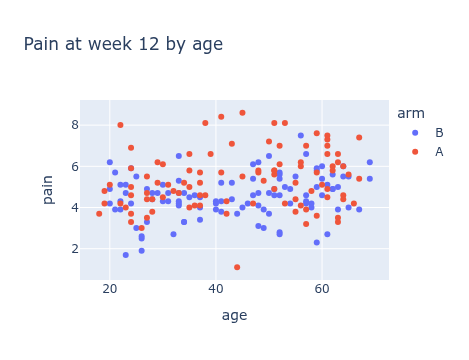

In [4]:
import plotly.express as px

px.scatter(week12, x="age", y="pain", color="arm", hover_data=["site"], title="Pain at week 12 by age")

## matplotlib, plotnine and ninejs

A figure is a thumbnail at Overview and a picture at Full and Compact. On a matplotlib figure, a box asks about the rows inside it when the axes name columns of a frame; on any other picture it asks about that area. ninejs turns a plotnine plot into an interactive one, with a tooltip for each point; it draws in a frame of its own, where a box asks nothing yet.

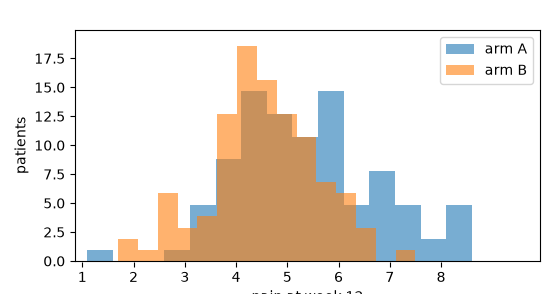

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 3))
for arm, part in week12.groupby("arm"):
    ax.hist(part.pain, bins=15, alpha=0.6, label=f"arm {arm}")
ax.set_xlabel("pain at week 12")
ax.set_ylabel("patients")
ax.legend();

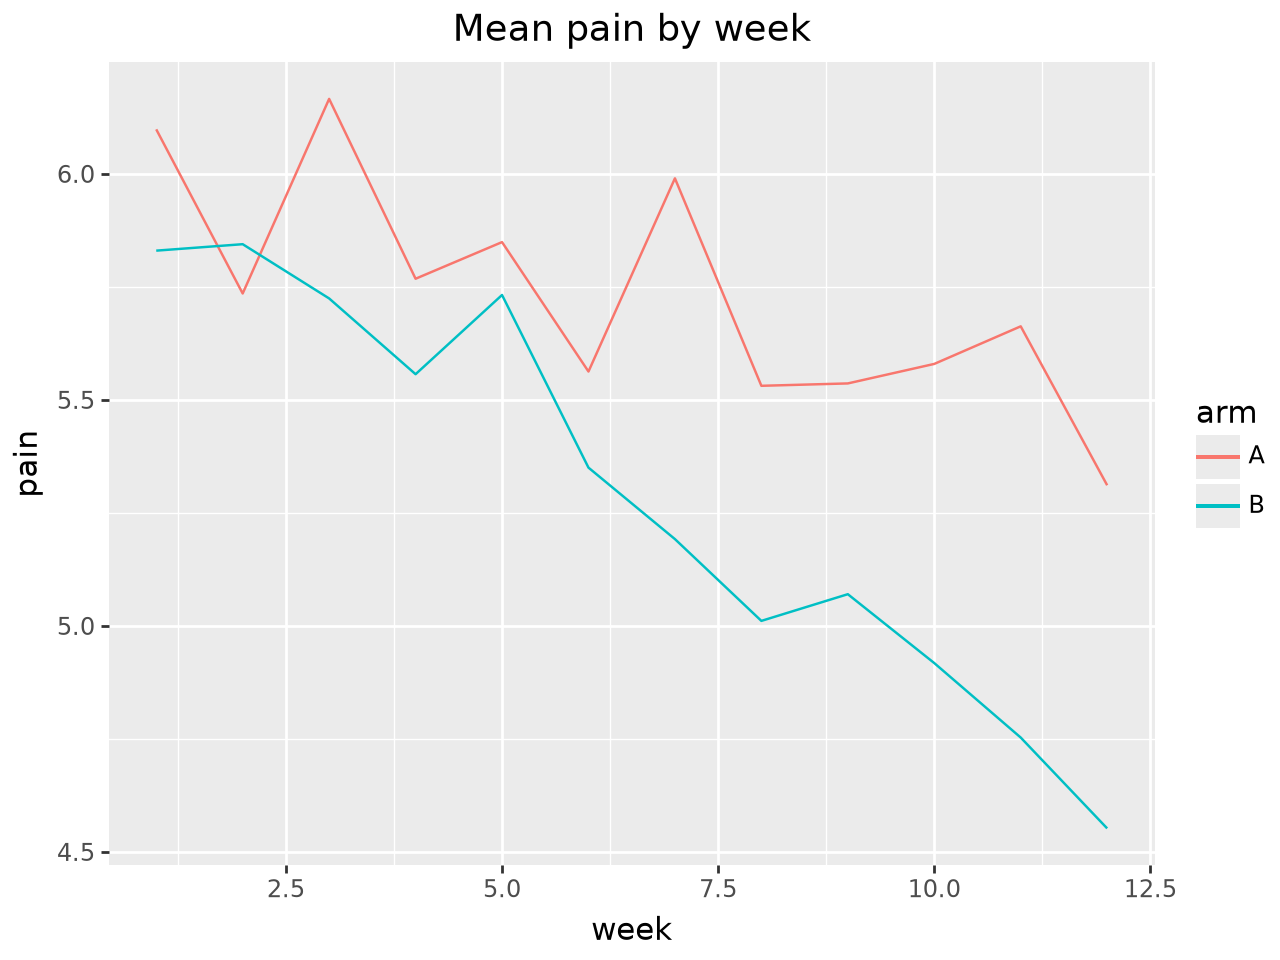

In [6]:
from plotnine import aes, geom_line, geom_point, ggplot, labs

weekly = visits.groupby(["week", "arm"], as_index=False).pain.mean()
ggplot(weekly, aes("week", "pain", color="arm")) + geom_line() + labs(title="Mean pain by week")

In [7]:
from ninejs import interactive

interactive(ggplot(week12, aes("age", "pain", color="arm", tooltip="site")) + geom_point())

## ipywidgets: a control that changes the answer

The slider sets a pain threshold, and the counts are the patients above it in each arm at week 12. The widget is live while the kernel runs.

In [8]:
from ipywidgets import interact


@interact(threshold=(0.0, 10.0, 0.5))
def above(threshold=6.0):
    return week12[week12.pain > threshold].groupby("arm").patient_id.nunique().rename("patients")

interactive(children=(FloatSlider(value=6.0, description='threshold', max=10.0, step=0.5), Output()), _dom_cla…

## ipympl: a live figure

`%matplotlib widget` switches matplotlib to ipympl for the cells after it. Zoom and pan with the tools beside the figure. On the bench the figure is a thumbnail of its first drawing.

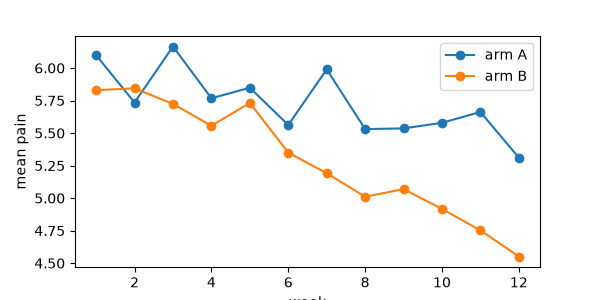

In [9]:
%matplotlib widget

fig2, ax2 = plt.subplots(figsize=(6, 3))
for arm, part in weekly.groupby("arm"):
    ax2.plot(part.week, part.pain, marker="o", label=f"arm {arm}")
ax2.set_xlabel("week")
ax2.set_ylabel("mean pain")
ax2.legend();

## Whybook's own plot

`epi.ribbon` draws the mean with its interval. Each mark keeps the rows behind it, so a brush across weeks asks about those rows, on the bench as in the Code view.

In [10]:
import whybook

whybook.ribbon(visits, x="week", y="pain", by="arm", title="Mean pain by week, with 95% intervals")

<whybook ribbon: Mean pain by week, with 95% intervals>